# Cheat Sheet — Pandas / Matplotlib / Seaborn for Tabular EDA
### Companion reference for the Automobile Fuel Efficiency lab

Every snippet below is runnable against `vehicles.csv` and mirrors a pattern used somewhere in the lab.
Keep this open in a side tab while you work through the skeleton notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

sns.set_theme(style="whitegrid")
vehicles = pd.read_csv("vehicles.csv", low_memory=False)


## 1. Loading & inspecting data

In [2]:
# pd.read_csv("file.csv", low_memory=False)   # avoid DtypeWarning on mixed-type columns (pseudo-code, edit path)
vehicles.shape                                     # (n_rows, n_cols)
len(vehicles)                                      # n_rows
len(vehicles.columns)                              # n_cols
vehicles.columns.tolist()                          # list of column names
vehicles.dtypes                                    # dtype per column
vehicles.head(); vehicles.tail(); vehicles.sample(5)
vehicles.info()
vehicles.describe()                                # summary stats for numeric columns


<class 'pandas.DataFrame'>
RangeIndex: 50242 entries, 0 to 50241
Data columns (total 84 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   barrels08        50242 non-null  float64
 1   barrelsA08       50242 non-null  float64
 2   charge120        50242 non-null  float64
 3   charge240        50242 non-null  float64
 4   city08           50242 non-null  int64  
 5   city08U          50242 non-null  float64
 6   cityA08          50242 non-null  int64  
 7   cityA08U         50242 non-null  float64
 8   cityCD           50242 non-null  float64
 9   cityE            50242 non-null  float64
 10  cityUF           50242 non-null  float64
 11  co2              50242 non-null  int64  
 12  co2A             50242 non-null  int64  
 13  co2TailpipeAGpm  50242 non-null  float64
 14  co2TailpipeGpm   50242 non-null  float64
 15  comb08           50242 non-null  int64  
 16  comb08U          50242 non-null  float64
 17  combA08          50242 

,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,UCity,UCityA,UHighway,UHighwayA,year,youSaveSpend,charge240b,phevCity,phevHwy,phevComb
count,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,...,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000,50242.000000
mean,14.853064,0.192270,0.000064,0.348662,20.997711,10.856866,0.980315,0.857563,0.000701,1.638885,...,27.036123,1.323081,37.529557,1.127984,2005.459814,-5732.738545,0.014599,0.375682,0.382330,0.376597
std,4.834742,0.986115,0.014276,1.880898,15.423219,19.350408,7.257852,7.191455,0.038715,8.346833,...,22.338777,10.301935,18.670675,7.683762,13.116531,5266.436645,0.312242,4.378506,4.259966,4.292850
min,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1984.000000,-43250.000000,0.000000,0.000000,0.000000,0.000000
25%,12.396250,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,18.888900,0.000000,28.499600,0.000000,1993.000000,-9000.000000,0.000000,0.000000,0.000000,0.000000
50%,14.875500,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,22.058400,0.000000,34.100000,0.000000,2006.000000,-5500.000000,0.000000,0.000000,0.000000,0.000000
75%,17.500588,0.000000,0.000000,0.000000,21.000000,18.544300,0.000000,0.000000,0.000000,0.000000,...,27.000000,0.000000,40.500000,0.000000,2017.000000,-2250.000000,0.000000,0.000000,0.000000,0.000000
max,42.501429,16.528333,3.200000,19.000000,153.000000,155.824200,145.000000,145.083500,5.350000,122.000000,...,224.800000,207.262200,198.800000,173.143600,2027.000000,11000.000000,9.600000,111.000000,91.000000,101.000000


## 2. Uniques & counts

In [3]:
vehicles["year"].nunique()          # count of distinct values
vehicles["year"].unique()           # array of distinct values
vehicles["year"].min(), vehicles["year"].max()
vehicles["fuelType1"].value_counts()          # frequency table (like R's table())
vehicles["fuelType1"].value_counts(normalize=True)   # as proportions


fuelType1
Regular Gasoline     0.623487
Premium Gasoline     0.313674
Electricity          0.031290
Diesel               0.026075
Midgrade Gasoline    0.003443
Natural Gas          0.001194
Hydrogen             0.000836
Name: proportion, dtype: float64

## 3. Deriving a column from string data

In [4]:
# First character of a string column
vehicles["trany2"] = vehicles["trany"].str[0]

# Contains / starts-with / regex extract
vehicles["make"].str.contains("Chev")
vehicles["make"].str.startswith("Che")
vehicles["trany"].str.extract(r"(\d+)-spd")   # pull out digits before '-spd'


,0
0,5
1,5
2,5
3,3
4,5
...,...
50237,4
50238,5
50239,4
50240,5


## 4. Filtering rows (boolean masks)

This is the single most important pattern in the whole lab — nearly everything downstream starts
with combining boolean Series with `&` (and), `|` (or), `~` (not). **Always wrap each condition in
parentheses** when combining with `&`/`|` — operator precedence will otherwise break your expression.

In [5]:
criteria1 = vehicles["fuelType1"].isin(["Regular Gasoline", "Premium Gasoline", "Midgrade Gasoline"])
criteria2 = vehicles["fuelType2"].isnull()          # or .notnull() for the opposite
criteria3 = vehicles["atvType"] != "Hybrid"

subset = vehicles[criteria1 & criteria2 & criteria3]     # AND
# subset = vehicles[criteria1 | criteria3]                # OR
# subset = vehicles[~criteria1]                           # NOT


## 5. Cleaning a numeric column that pandas loaded as mixed/object dtype

In [6]:
clean = vehicles[vehicles["displ"].notnull()].copy()   # drop NaNs first
clean["displ"] = clean["displ"].astype(float)          # then cast safely


## 6. Split-apply-combine (`groupby`)

The pandas equivalent of R's `plyr::ddply` / `dplyr::group_by() %>% summarise()`.

In [7]:
# Single column, single stat
vehicles.groupby("year")["comb08"].mean()

# Multiple columns, single stat  -- NOTE the double brackets: a LIST of column names
vehicles.groupby("year")[["comb08", "highway08", "city08"]].mean()

# Multiple stats at once
vehicles.groupby("year")["comb08"].agg(["mean", "std", "count"])

# Multiple grouping keys
vehicles.groupby(["year", "make"])["comb08"].mean()

# Turn the group-by index back into ordinary column(s) for plotting/merging
vehicles.groupby(["year", "make"])["comb08"].mean().reset_index()

# Number of distinct values per group
vehicles.groupby("year")["make"].nunique()

# Iterate manually over groups if you need custom per-group logic
for year, group in vehicles.groupby("year"):
    pass   # `group` is the sub-DataFrame for that year


> ⚠️ **Deprecated syntax to avoid:** `grouped['a', 'b'].agg([np.mean])` (from the original 2017
> book) raises errors/FutureWarnings on modern pandas. Always pass a **list**: `grouped[['a','b']].mean()`.

## 7. Wide ↔ long reshaping (for faceted/multi-series plots)

In [8]:
wide = vehicles.groupby("year")[["comb08", "displ"]].mean().reset_index()

long = wide.melt(id_vars="year", value_vars=["comb08", "displ"],
                  var_name="variable", value_name="value")

# Inverse operation: long -> wide
back_to_wide = long.pivot(index="year", columns="variable", values="value")


## 8. Set operations across groups (find items common to every group)

In [9]:
per_year_sets = [set(g["make"].unique()) for _, g in vehicles.groupby("year")]
makes_in_every_year = reduce(set.intersection, per_year_sets)


## 9. Plotting recipes

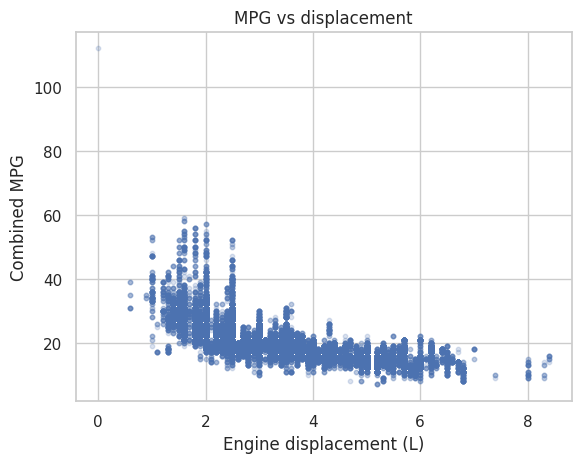

In [10]:
# Scatter
fig, ax = plt.subplots()
ax.scatter(vehicles["displ"], vehicles["comb08"], alpha=0.2, s=10)
ax.set_xlabel("Engine displacement (L)"); ax.set_ylabel("Combined MPG")
ax.set_title("MPG vs displacement")
plt.show()


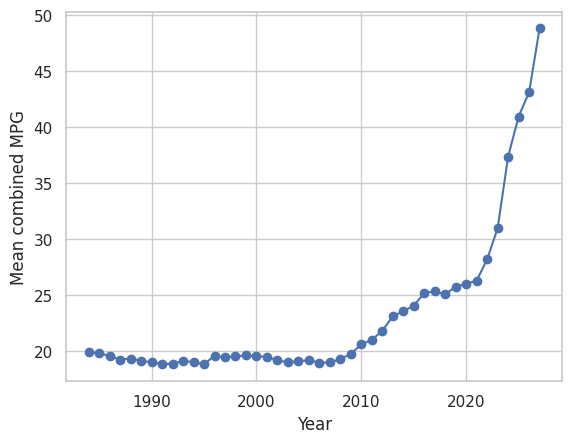

In [11]:
# Line plot of a time trend
by_year = vehicles.groupby("year")["comb08"].mean()
fig, ax = plt.subplots()
ax.plot(by_year.index, by_year.values, marker="o")
ax.set_xlabel("Year"); ax.set_ylabel("Mean combined MPG")
plt.show()


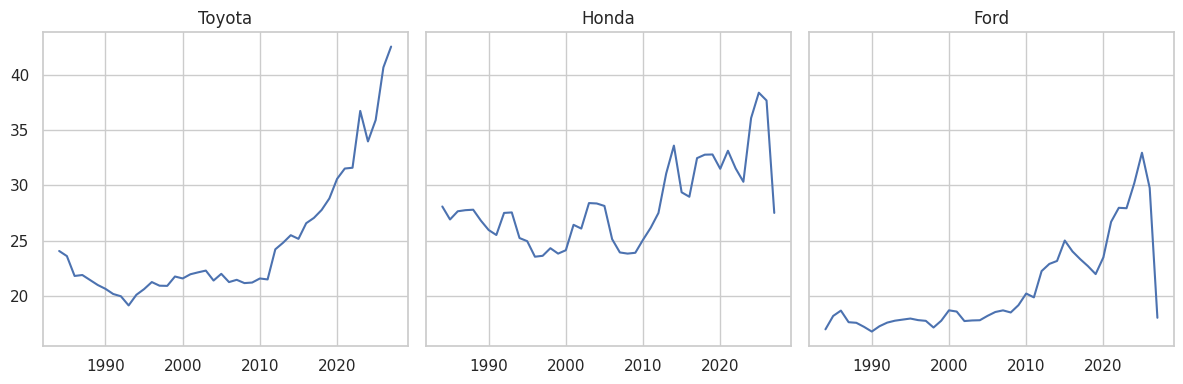

In [12]:
# Small multiples / facets (one subplot per category)
makes = ["Toyota", "Honda", "Ford"]
fig, axes = plt.subplots(1, len(makes), figsize=(12, 4), sharey=True)
for ax, mk in zip(axes, makes):
    sub = vehicles[vehicles["make"] == mk].groupby("year")["comb08"].mean()
    ax.plot(sub.index, sub.values)
    ax.set_title(mk)
plt.tight_layout(); plt.show()


/tmp/ipykernel_629/2847344753.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


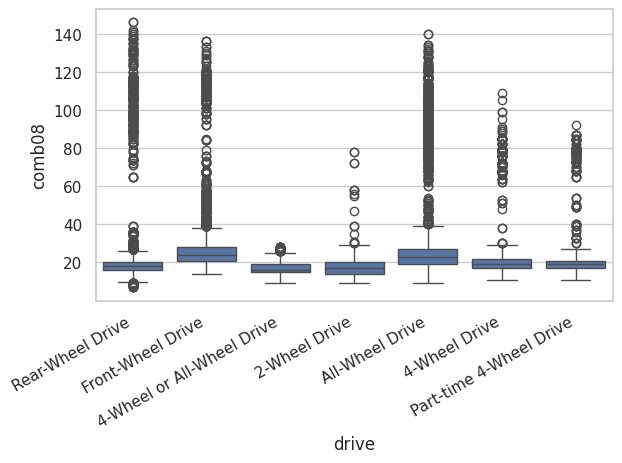

In [13]:
# Boxplot by category (seaborn)
fig, ax = plt.subplots()
sns.boxplot(data=vehicles, x="drive", y="comb08", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout(); plt.show()


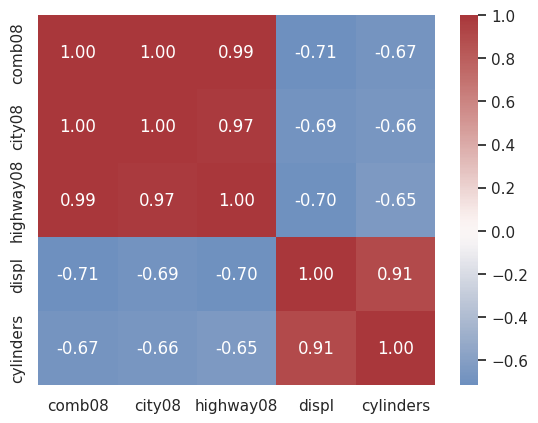

In [14]:
# Correlation heatmap
corr = vehicles[["comb08", "city08", "highway08", "displ", "cylinders"]].corr()
fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
plt.show()


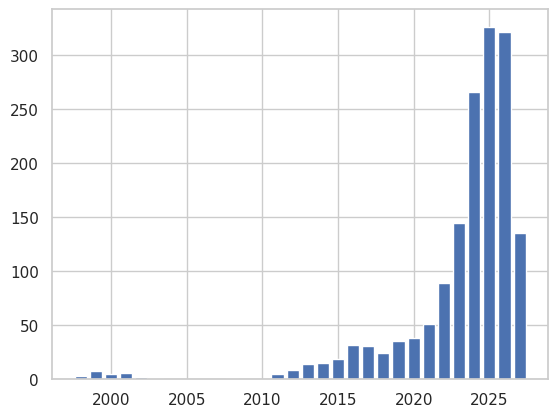

In [15]:
# Bar chart of counts over time
counts = vehicles[vehicles["fuelType1"] == "Electricity"].groupby("year").size()
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)
plt.show()


## 10. R ↔ Python quick-reference

| Task | R | Python / pandas |
|---|---|---|
| Row count | `nrow(df)` | `len(df)` |
| Column count | `ncol(df)` | `len(df.columns)` |
| Frequency table | `table(df$x)` | `df["x"].value_counts()` |
| Unique values | `unique(df$x)` | `df["x"].unique()` |
| Group + summarise | `ddply(df, "g", summarise, m=mean(x))` | `df.groupby("g")["x"].mean()` |
| Wide -> long | `melt(df, id.vars="g")` | `df.melt(id_vars="g")` |
| Grammar-of-graphics plotting | `ggplot2` | `matplotlib` / `seaborn` (imperative, not grammar-based) |


## 11. Common pitfalls checklist

- [ ] Did you use `low_memory=False` (or explicit `dtype=`) when a CSV throws a `DtypeWarning`?
- [ ] Did you drop/cast `NaN`s **before** calling `.astype(float)`?
- [ ] Did you wrap each condition in parentheses before combining with `&` / `|`?
- [ ] After a multi-key `groupby`, did you call `.reset_index()` before plotting/merging?
- [ ] Are you accidentally averaging **MPGe** (electric) together with **MPG** (gasoline)? Filter by
      `fuelType1`/`atvType` first.
- [ ] Are you using `df.groupby(...)[["a","b"]]` (list, double brackets) rather than the deprecated
      `df.groupby(...)['a','b']` (tuple, single brackets)?
